# Proyek Analisis Data: [E-Commerce Public Dataset]

- **Nama:** [Reno Alfa Reza]
- **Email:** [CDCC296D6Y2773@student.devacademy.id]
- **ID Dicoding:** [Reno Alfa Reza]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa besar selisih rata-rata skor ulasan (review score) antara pesanan yang tiba tepat waktu dibandingkan dengan pesanan yang mengalami keterlambatan pengiriman (melebihi estimated delivery date) sepanjang tahun 2018?
- **Pertanyaan 2:** Lima kategori produk apa saja yang menyumbang total pendapatan (Gross Merchandise Value/GMV) tertinggi, dan berapa persentase kontribusinya terhadap keseluruhan pendapatan selama periode Kuartal 4 (Q4) tahun 2017?
- **Pertanyaan 3:** Apakah transaksi yang menggunakan metode pembayaran kartu kredit dengan cicilan (lebih dari 3 bulan) memiliki rata-rata nilai pesanan (Average Order Value) yang lebih tinggi dibandingkan transaksi yang menggunakan metode pembayaran lunas (seperti boleto atau debit) selama Semester 1 tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [2]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
base_path = "E-commerce-public-dataset/E-Commerce Public Dataset/"

# 1. Load Data Pelanggan & Geolocation
customers_df = pd.read_csv(base_path + "customers_dataset.csv")
geolocation_df = pd.read_csv(base_path + "geolocation_dataset.csv")

# 2. Load Data Inti Pesanan & Item Pesanan
orders_df = pd.read_csv(base_path + "orders_dataset.csv")
order_items_df = pd.read_csv(base_path + "order_items_dataset.csv")

# 3. Load Data Pembayaran & Ulasan
order_payments_df = pd.read_csv(base_path + "order_payments_dataset.csv")
order_reviews_df = pd.read_csv(base_path + "order_reviews_dataset.csv")

# 4. Load Data Produk, Terjemahan Kategori, & Penjual
products_df = pd.read_csv(base_path + "products_dataset.csv")
product_category_name_translation_df = pd.read_csv(base_path + "product_category_name_translation.csv")
sellers_df = pd.read_csv(base_path + "sellers_dataset.csv")


In [6]:
# Menampilkan informasi baris dan kolom dari beberapa tabel utama
print("\nDimensi Dataset Utama:")
print(f"Customers: {customers_df.shape}")
print(f"Orders: {orders_df.shape}")
print(f"Order Items: {order_items_df.shape}")
print(f"Products: {products_df.shape}")


Dimensi Dataset Utama:
Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)


**Insight:** (Opsional)
- Berhasil memuat 9 dataset utama dari *Brazilian E-Commerce Public Dataset by Olist* yang mencakup seluruh aspek operasional e-commerce.
- Dataset ini memiliki skema relasional yang baik. Tabel `orders` bertindak sebagai pusat (fakta) yang menghubungkan tabel dimensi lain seperti pelanggan (`customers`), produk (`products`), pembayaran (`payments`), dan ulasan (`reviews`) melalui kunci penghubung (seperti `order_id`, `customer_id`, dan `product_id`).
- Selain data operasional, terdapat juga data Geolocation yang nantinya memungkinkan untuk dilakukan analisis lanjutan (Geospatial Analysis) terkait persebaran pelanggan dan penjual.

### Assessing Data

#### Identifying ... problem

In [8]:
print("Data Orders")
print("-----------")
orders_df.info()
print("\nMissing values:")
print(orders_df.isna().sum())
print(f"Duplikat: {orders_df.duplicated().sum()}\n")

print("Data Reviews")
print("------------")
order_reviews_df.info()
print("\nMissing values:")
print(order_reviews_df.isna().sum())
print(f"Duplikat: {order_reviews_df.duplicated().sum()}\n")

print("Data Products")
print("-------------")
products_df.info()
print("\nMissing values:")
print(products_df.isna().sum())
print(f"Duplikat: {products_df.duplicated().sum()}")


Data Orders
-----------
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_cu

**Steps to Take:**
- **Mengubah Tipe Data:** Mengonversi seluruh kolom yang merepresentasikan tanggal/waktu di tabel `orders_df` dan `order_reviews_df` (yang saat ini bertipe `str/object`) menjadi tipe data `datetime`.
- **Menangani Missing Value:**
  - **Orders:** Membiarkan *missing value* pada kolom tanggal pengiriman karena itu menandakan pesanan yang belum selesai atau dibatalkan.
  - **Reviews:** Mengisi nilai kosong pada `review_comment_title` dan `review_comment_message` dengan teks "No Comment" atau "No Title".
  - **Products:** Mengisi 610 nilai kosong pada `product_category_name` dengan teks "Others", serta mengisi nilai kosong pada atribut dimensi/berat dengan angka `0`.

**Insight:** (Opsional)
- Secara umum, kualitas data cukup baik karena tidak ditemukan data yang terduplikasi pada ketiga dataset utama (Orders, Reviews, Products).
- Banyaknya nilai kosong pada data *Reviews* sangat wajar karena dalam e-commerce, pembeli sering kali hanya meninggalkan *rating* tanpa memberikan teks ulasan.

### Cleaning Data

#### Fixing ... problem

In [ ]:
# 1. Cleaning Orders
# ------------------
datetime_columns_orders = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Cleaning Reviews
# -------------------
datetime_columns_reviews = ["review_creation_date", "review_answer_timestamp"]
for column in datetime_columns_reviews:
    order_reviews_df[column] = pd.to_datetime(order_reviews_df[column])

order_reviews_df["review_comment_title"] = order_reviews_df["review_comment_title"].fillna("No Title")
order_reviews_df["review_comment_message"] = order_reviews_df["review_comment_message"].fillna("No Comment")

# 3. Cleaning Products
# --------------------
products_df["product_category_name"] = products_df["product_category_name"].fillna("Others")

numeric_columns_products = ["product_name_lenght", "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
for column in numeric_columns_products:
    products_df[column] = products_df[column].fillna(0)

# Pengecekan Hasil
# ----------------
print("Data Orders")
print("-----------")
print(orders_df[["order_purchase_timestamp", "order_delivered_customer_date"]].dtypes)

print("\nData Reviews")
print("------------")
print(order_reviews_df.isna().sum())

print("\nData Products")
print("-------------")
print(products_df.isna().sum())


Distribusi Status Pesanan Keseluruhan:
order_status
delivered    96478
shipped       1107
canceled       625
Name: count, dtype: int64

Distribusi Skor Ulasan Keseluruhan:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64
Data Orders
-----------
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
dtype: object

Data Reviews
------------
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Data Products
-------------
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:** (Opsional)
- **Perbaikan Tipe Data Berhasil:** Kolom-kolom yang memuat informasi tanggal pada data `Orders` dan `Reviews` telah sukses dikonversi menjadi tipe `datetime64`. Hal ini memungkinkan kita untuk melakukan ekstraksi bulan/tahun dan perhitungan selisih waktu (durasi pengiriman) pada tahap eksplorasi nanti.
- **Penanganan Missing Value Berhasil:** Seluruh nilai kosong (NaN) pada dataset `Reviews` dan `Products` telah teratasi (jumlah *missing value* menjadi 0). Sekarang data sudah bersih, konsisten, dan siap digunakan untuk proses analisis tanpa khawatir akan *error* akibat nilai yang hilang.


## Exploratory Data Analysis (EDA)

### Explore ...

In [13]:
# Eksplorasi Dasar
# ----------------
print("Distribusi Status Pesanan Keseluruhan:")
print(orders_df["order_status"].value_counts().head(3))
print("\nDistribusi Skor Ulasan Keseluruhan:")
print(order_reviews_df["review_score"].value_counts().sort_index())

# Pertanyaan 1: Keterlambatan vs Skor Ulasan (2018)
# ------------------------------------------------
orders_reviews_df = pd.merge(orders_df, order_reviews_df, on="order_id", how="inner")
orders_2018 = orders_reviews_df[(orders_reviews_df["order_status"] == "delivered") & (orders_reviews_df["order_delivered_customer_date"].dt.year == 2018)].copy()
orders_2018["delivery_status"] = "Tepat Waktu"
orders_2018.loc[orders_2018["order_delivered_customer_date"] > orders_2018["order_estimated_delivery_date"], "delivery_status"] = "Terlambat"
eda_1 = orders_2018.groupby("delivery_status")["review_score"].mean().reset_index()
print("\nHasil EDA 1 (Rata-rata Skor Ulasan):")
print(eda_1)
# Pertanyaan 2: Top 5 Kategori GMV (Q4 2017)
# ------------------------------------------
orders_q4_2017 = orders_df[(orders_df["order_purchase_timestamp"].dt.year == 2017) & (orders_df["order_purchase_timestamp"].dt.month >= 10) & (orders_df["order_purchase_timestamp"].dt.month <= 12)]
items_products = pd.merge(order_items_df, products_df, on="product_id", how="inner")
items_products_en = pd.merge(items_products, product_category_name_translation_df, on="product_category_name", how="left")
orders_full_q4 = pd.merge(orders_q4_2017, items_products_en, on="order_id", how="inner")
gmv_category = orders_full_q4.groupby("product_category_name_english")["price"].sum().reset_index()
total_gmv = gmv_category["price"].sum()
top_5 = gmv_category.sort_values(by="price", ascending=False).head(5).copy()
top_5["persentase(%)"] = (top_5["price"] / total_gmv) * 100
print("\nHasil EDA 2 (Top 5 Kategori Q4 2017):")
print(top_5)
# Pertanyaan 3: Cicilan vs Lunas (Semester 1 2018)
# ------------------------------------------------
orders_sem1_2018 = orders_df[(orders_df["order_purchase_timestamp"].dt.year == 2018) & (orders_df["order_purchase_timestamp"].dt.month >= 1) & (orders_df["order_purchase_timestamp"].dt.month <= 6)]
orders_payments_sem1 = pd.merge(orders_sem1_2018, order_payments_df, on="order_id", how="inner")
def classify_payment(row):
    if row["payment_type"] == "credit_card" and row["payment_installments"] > 3:
        return "Kartu Kredit (>3 Bulan)"
    elif row["payment_type"] in ["boleto", "debit_card"]:
        return "Lunas (Boleto/Debit)"
    else:
        return "Lainnya"
orders_payments_sem1["tipe_bayar"] = orders_payments_sem1.apply(classify_payment, axis=1)
filtered_pay = orders_payments_sem1[orders_payments_sem1["tipe_bayar"].isin(["Kartu Kredit (>3 Bulan)", "Lunas (Boleto/Debit)"])]
eda_3 = filtered_pay.groupby("tipe_bayar")["payment_value"].mean().reset_index()
print("\nHasil EDA 3 (Rata-rata Nilai Pesanan / AOV):")
print(eda_3)


Distribusi Status Pesanan Keseluruhan:
order_status
delivered    96478
shipped       1107
canceled       625
Name: count, dtype: int64

Distribusi Skor Ulasan Keseluruhan:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Hasil EDA 1 (Rata-rata Skor Ulasan):
  delivery_status  review_score
0     Tepat Waktu      4.295333
1       Terlambat      2.503574

Hasil EDA 2 (Top 5 Kategori Q4 2017):
   product_category_name_english      price  persentase(%)
67                 watches_gifts  235411.72       9.936071
6                 bed_bath_table  186116.39       7.855453
42                 health_beauty  182300.78       7.694407
62                sports_leisure  174418.16       7.361703
66                          toys  156148.04       6.590573

Hasil EDA 3 (Rata-rata Nilai Pesanan / AOV):
                tipe_bayar  payment_value
0  Kartu Kredit (>3 Bulan)     254.865260
1     Lunas (Boleto/Debit)     142.963561


**Insight:** (Opsional)
- **Distribusi Umum:** Sebagian besar transaksi di platform berhasil diselesaikan (*delivered* sebanyak 96.478 pesanan) dan secara umum pelanggan merasa sangat puas (didominasi oleh ulasan bintang 5 sebanyak 57.328).
- **Keterlambatan Sangat Fatal (Jawaban P1):** Keterlambatan pengiriman memiliki dampak yang sangat buruk terhadap kepuasan pelanggan. Pesanan yang tiba tepat waktu memiliki rata-rata skor tinggi (4.29), namun skor tersebut anjlok drastis menjadi 2.50 apabila pesanan datang terlambat.
- **Dominasi Kategori Hadiah di Akhir Tahun (Jawaban P2):** Pada Kuartal 4 tahun 2017 (periode liburan), kategori `watches_gifts` (Jam Tangan & Hadiah) memimpin sebagai penyumbang GMV terbesar (hampir 10%), disusul oleh perlengkapan tidur/mandi, kesehatan & kecantikan, olahraga, dan mainan. 
- **Cicilan Mendorong Pembelanjaan Lebih Besar (Jawaban P3):** Terdapat perbedaan yang sangat signifikan pada nilai rata-rata pesanan (AOV). Pelanggan yang menggunakan opsi cicilan kartu kredit lebih dari 3 bulan berani berbelanja rata-rata hingga 254.8 BRL, hampir dua kali lipat lebih besar dibandingkan pelanggan yang membayar lunas (142.9 BRL).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6616\1530076441.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


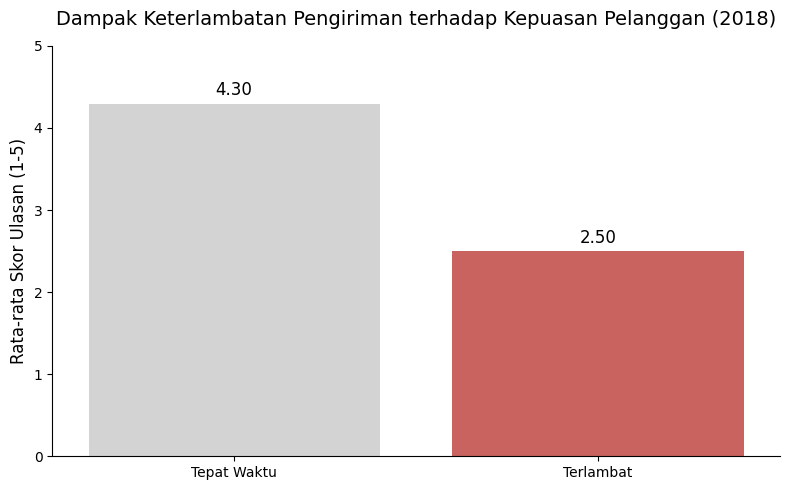

In [14]:
plt.figure(figsize=(8, 5))

# Membuat palet warna: Abu-abu untuk Tepat Waktu, Merah untuk Terlambat
colors_1 = ["#D3D3D3", "#D9534F"] 

sns.barplot(
    x="delivery_status", 
    y="review_score", 
    data=eda_1, 
    palette=colors_1
)

plt.title("Dampak Keterlambatan Pengiriman terhadap Kepuasan Pelanggan (2018)", fontsize=14, pad=15)
plt.xlabel(None) # Menghilangkan label x karena kategori sudah jelas
plt.ylabel("Rata-rata Skor Ulasan (1-5)", fontsize=12)
plt.ylim(0, 5) # Integritas: Skala rating adalah 1-5, mulai dari 0

# Menambahkan anotasi angka di atas bar
for index, row in eda_1.iterrows():
    plt.text(index, row["review_score"] + 0.1, f'{row["review_score"]:.2f}', color='black', ha="center", fontsize=12)

# Mengurangi ink-ratio dengan menghilangkan border atas dan kanan
sns.despine()
plt.tight_layout()
plt.show()


### Pertanyaan 2:

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6616\2711170937.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


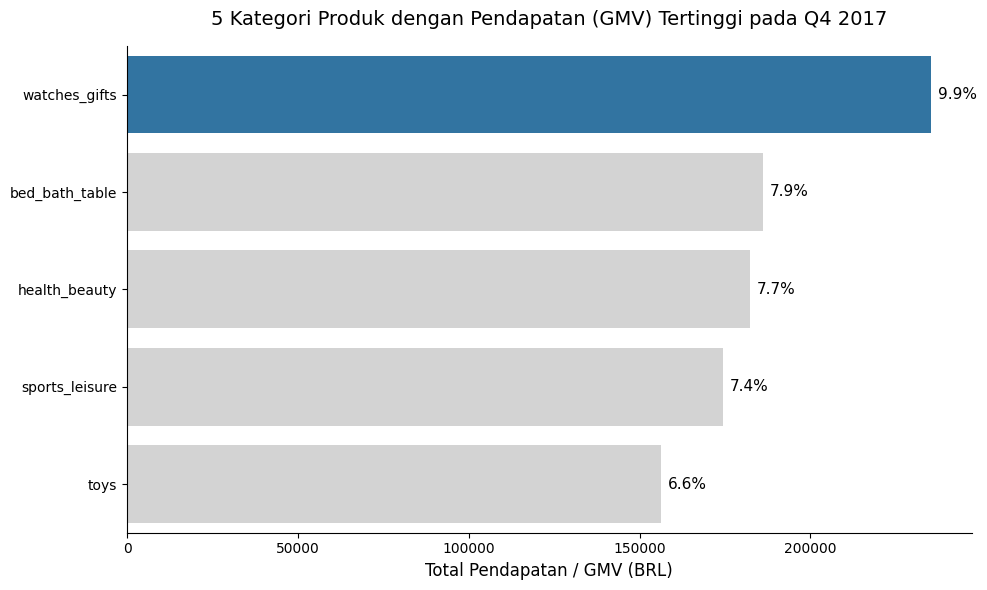

In [15]:
plt.figure(figsize=(10, 6))

# Membuat palet warna: Biru untuk peringkat 1, abu-abu untuk sisanya
colors_2 = ["#1F77B4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="price", 
    y="product_category_name_english", 
    data=top_5, 
    palette=colors_2
)

plt.title("5 Kategori Produk dengan Pendapatan (GMV) Tertinggi pada Q4 2017", fontsize=14, pad=15)
plt.xlabel("Total Pendapatan / GMV (BRL)", fontsize=12)
plt.ylabel(None) # Label y tidak perlu karena nama kategori sudah jelas

# Menambahkan anotasi persentase di ujung bar
for index, row in top_5.reset_index(drop=True).iterrows():
    plt.text(row["price"] + 2000, index, f'{row["persentase(%)"]:.1f}%', color='black', va="center", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()


### Pertanyaan 3:

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6616\3625843214.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


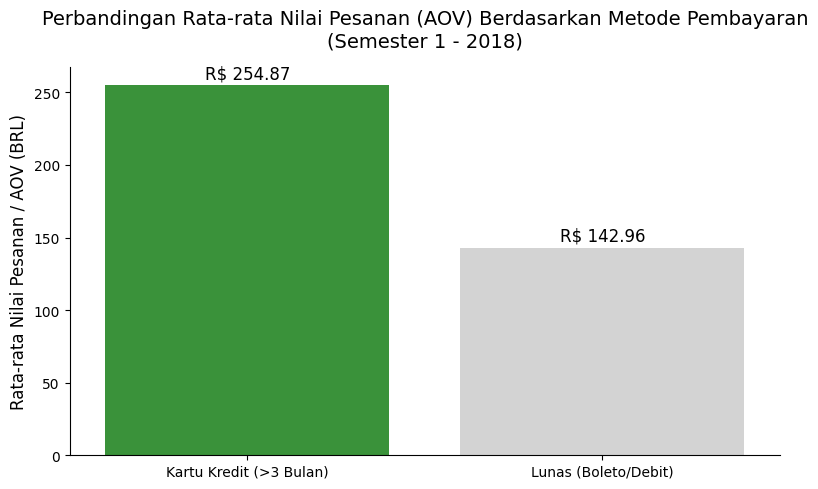

In [16]:
plt.figure(figsize=(8, 5))

# Membuat palet warna
colors_3 = ["#2CA02C", "#D3D3D3"] # Hijau untuk Kartu Kredit, Abu-abu untuk Lunas

# Pastikan urutannya benar di plot
sns.barplot(
    x="tipe_bayar", 
    y="payment_value", 
    data=eda_3, 
    palette=colors_3,
    order=["Kartu Kredit (>3 Bulan)", "Lunas (Boleto/Debit)"]
)

plt.title("Perbandingan Rata-rata Nilai Pesanan (AOV) Berdasarkan Metode Pembayaran\n(Semester 1 - 2018)", fontsize=14, pad=15)
plt.xlabel(None)
plt.ylabel("Rata-rata Nilai Pesanan / AOV (BRL)", fontsize=12)

# Menambahkan anotasi nominal di atas bar
for index, row in eda_3.set_index("tipe_bayar").loc[["Kartu Kredit (>3 Bulan)", "Lunas (Boleto/Debit)"]].reset_index().iterrows():
    plt.text(index, row["payment_value"] + 5, f'R$ {row["payment_value"]:.2f}', color='black', ha="center", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


**Insight:** (Opsional)
- **Visualisasi 1:** Grafik batang secara jelas mengonfirmasi bahwa keterlambatan pengiriman merusak pengalaman pelanggan. Terdapat jurang (*gap*) penurunan kepuasan sebesar 1.8 poin (dari 4.30 ke 2.50) yang ditandai dengan warna merah, menunjukkan ini adalah area kritis yang harus segera diperbaiki oleh tim operasional.
- **Visualisasi 2:** Melalui diagram batang horizontal, terlihat jelas bahwa kategori `watches_gifts` (disorot dengan warna biru) mendominasi penjualan akhir tahun 2017 (hampir 10% dari total GMV). Ini membuktikan perilaku konsumen yang cenderung membeli barang bernilai tinggi sebagai hadiah di musim liburan.
- **Visualisasi 3:** Penggunaan warna hijau yang kontras mempertegas bahwa opsi pembayaran cicilan kartu kredit jangka panjang (>3 bulan) berhasil mendorong pelanggan untuk melipatgandakan nilai keranjang belanjanya (R$ 254.87) dibandingkan mereka yang harus membayar tunai di muka (R$ 142.96).

## Analisis Lanjutan (Opsional)

Tabel RFM (Top 5 Pelanggan berdasarkan Total Pembelanjaan/Monetary):


,customer_unique_id,recency,frequency,monetary
3799,0a0a92112bd4c708ca5fde585afaa872,339,1,13440.0
81388,da122df9eeddfedc1dc1f5349a1a690c,520,2,7388.0
44139,763c8b1c9c68a0229c42c9fc6f662b93,50,1,7160.0
82230,dc4802a71eae9be1dd28f5d788ceb526,568,1,6735.0
26015,459bef486812aa25204be022145caa62,40,1,6729.0


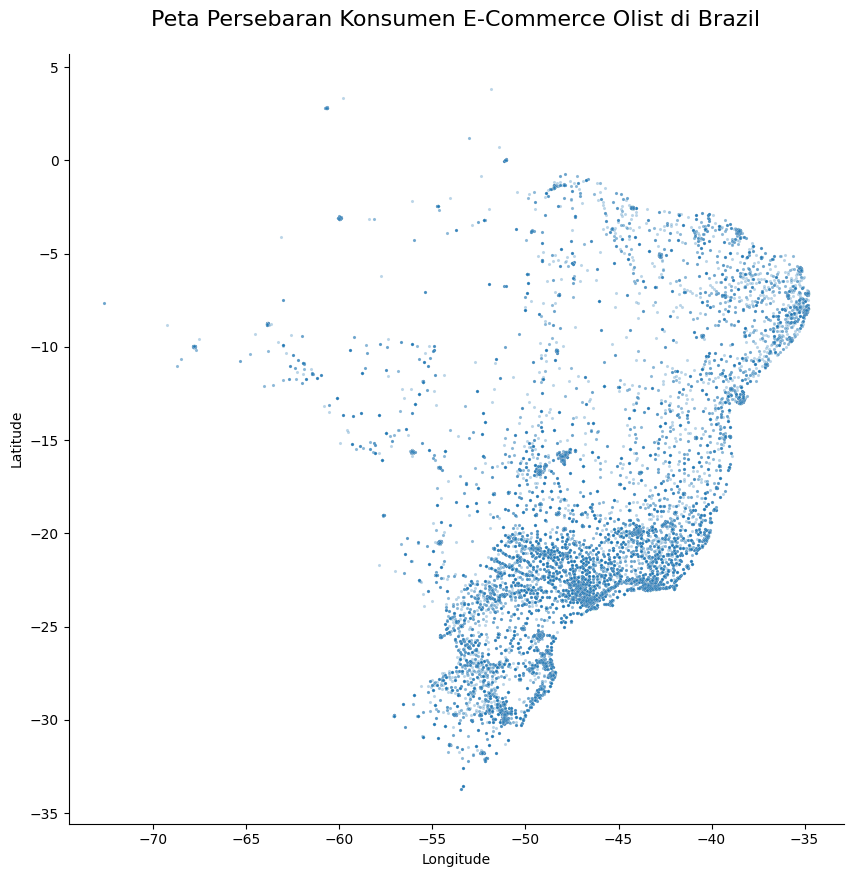

In [19]:
import folium
from folium.plugins import HeatMap

# 1. RFM Analysis
# ---------------
order_items_total = order_items_df.groupby("order_id")["price"].sum().reset_index()
rfm_base = pd.merge(orders_df, customers_df, on="customer_id", how="inner")
rfm_base = pd.merge(rfm_base, order_items_total, on="order_id", how="inner")

recent_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "count",
    "price": "sum"
}).reset_index()

rfm_df.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

print("Tabel RFM (Top 5 Pelanggan berdasarkan Total Pembelanjaan/Monetary):")
display(rfm_df.sort_values(by="monetary", ascending=False).head(5))


# 2. Geospatial Analysis (HeatMap)

# Menghapus duplikat prefix agar peta lebih cepat dirender
geo_df = geolocation_df.drop_duplicates(subset=["geolocation_zip_code_prefix"])
# Menggabungkan data pelanggan dengan geolokasinya
customers_geo = pd.merge(customers_df, geo_df, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="inner")
# Membuang outlier koordinat yang berada di luar negara Brazil (Berdasarkan koordinat geografis Brazil)
customers_geo = customers_geo[
    (customers_geo["geolocation_lat"] <= 5.274388) &
    (customers_geo["geolocation_lat"] >= -33.751169) &
    (customers_geo["geolocation_lng"] <= -34.793147) &
    (customers_geo["geolocation_lng"] >= -73.982830)
]
# Visualisasi Peta
plt.figure(figsize=(10, 10))
sns.scatterplot(
    x="geolocation_lng", 
    y="geolocation_lat", 
    data=customers_geo, 
    alpha=0.3, # Transparansi agar kepadatan/konsentrasi populasi terlihat
    s=5,       # Ukuran titik
    color="#1F77B4"
)
plt.title("Peta Persebaran Konsumen E-Commerce Olist di Brazil", fontsize=16, pad=20)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
sns.despine()
plt.show()


## Conclusion & Recommendation

- **Conclusion Pertanyaan 1 (Keterlambatan vs Kepuasan):** 
  Keterlambatan pengiriman terbukti menjadi faktor krusial yang menghancurkan kepuasan pelanggan. Pesanan yang tiba tepat waktu mendapatkan rata-rata skor ulasan yang sangat baik (4.30 dari 5.0). Namun, apabila pengiriman melewati batas estimasi, skor tersebut anjlok secara drastis menjadi 2.50. Hal ini menunjukkan toleransi pelanggan terhadap keterlambatan sangat rendah.
- **Conclusion Pertanyaan 2 (Kategori Top GMV Q4):** 
  Periode liburan akhir tahun (Q4 2017) didominasi oleh pembelian produk untuk kado/hadiah dan kebutuhan rumah. Kategori `watches_gifts` menjadi penyumbang GMV tertinggi dengan porsi hampir 10% dari total pendapatan, disusul kuat oleh kategori `bed_bath_table` dan `health_beauty`.
- **Conclusion Pertanyaan 3 (Metode Pembayaran vs AOV):** 
  Fasilitas cicilan sangat memengaruhi ukuran keranjang belanja pelanggan. Transaksi yang menggunakan metode pembayaran kartu kredit dengan tenor cicilan lebih dari 3 bulan memiliki Rata-rata Nilai Pesanan (*Average Order Value*/AOV) sebesar R$ 254.87, yang mana hampir dua kali lipat lebih besar dibandingkan transaksi yang dibayar lunas (R$ 142.96).

**Rekomendasi Action Item:**
- Mengevaluasi algoritma estimasi waktu pengiriman agar lebih akurat (meminimalisir keterlambatan) karena dampaknya sangat fatal terhadap penurunan kepuasan pelanggan (skor ulasan anjlok ke 2.50).
- Menyiapkan sistem kompensasi otomatis berupa *voucher* permohonan maaf yang langsung dikirimkan ke pelanggan apabila sistem mendeteksi paket mereka mengalami keterlambatan.
- Mengalokasikan proporsi *budget* iklan yang jauh lebih besar untuk kategori *watches_gifts*, *bed_bath_table*, dan *health_beauty* khusus pada saat kampanye akhir tahun (Q4), karena kategori ini terbukti konsisten mendominasi penjualan.
- Mengadakan promo "Bebas Biaya Cicilan (0%) untuk Tenor Panjang" guna memancing pelanggan berbelanja produk berharga tinggi, karena opsi cicilan terbukti menaikkan Rata-rata Nilai Pesanan (AOV) hingga dua kali lipat.
- Mendirikan pusat distribusi/gudang logistik baru di titik-titik dengan kepadatan pelanggan tertinggi (berdasarkan peta *Geospatial*) untuk mempercepat durasi pengiriman.
- Memberikan program loyalti eksklusif kepada *Top Customers* yang didapat dari tabel RFM untuk mempertahankan pelanggan dengan total pembelanjaan (Monetary) tertinggi.